In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r'C:\Users\shreyaash mogaveera\MedBot\data\dataset.csv')

In [3]:
symptom_cols=[col for col in df.columns if col.startswith('Symptom_')]

for col in symptom_cols:
    df[col]=df[col].str.strip()
    df[col]=df[col].str.replace(' ','_')
    df[col]=df[col].str.lower()

In [4]:
symptom_columns=joblib.load('../model/symptom_columns.pkl')
le=joblib.load('../model/label_encoder.pkl')

In [5]:
X=pd.DataFrame(0,index=df.index,columns=symptom_columns)
for col in symptom_cols:
    for idx,symptom in df[col].items():
        if pd.notna(symptom) and symptom in X.columns:
            X.loc[idx,symptom]=1
y=le.transform(df['Disease'])

In [6]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)

In [8]:
#adding noise to simulate real world data from user(if user forgets to mention some sympotms or if user is confused )
def add_symptom_noise(X,y,noise_level=0.1):
    X_noisy=X.copy()

    for idx in range(len(X_noisy)):
        #dropping some percent of symptoms randomly
        present_symptoms=np.where(X_noisy.iloc[idx]==1)[0]
        n_to_drop=max(1,int(len(present_symptoms)*noise_level))

        if len(present_symptoms)>2:
            #keep atleast two symptoms
            drop_indices=np.random.choice(present_symptoms,size=min(n_to_drop,len(present_symptoms)-2),replace=False)
            X_noisy.iloc[idx,drop_indices] = 0
    return X_noisy,y

In [9]:
np.random.seed(42)
X_noisy,y_noisy=add_symptom_noise(X_train,y_train,noise_level=0.15) 

In [10]:
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_noisy,y_noisy)
dt_pred=dt.predict(X_test)
print(f"Decision tree:{accuracy_score(y_test,dt_pred):.4f}")

Decision tree:1.0000


In [11]:
ada=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3),
                      n_estimators=200,learning_rate=0.5,
                      random_state=42)
ada.fit(X_noisy,y_noisy)
ada_pred=ada.predict(X_test)
print(f"AdaBoost:{accuracy_score(y_test,ada_pred):.4f}")

AdaBoost:0.9990


In [12]:
rf=RandomForestClassifier(n_estimators=100,max_depth=12,random_state=42)
rf.fit(X_noisy,y_noisy)
rf_pred=rf.predict(X_test)
print(f"Random forest:{accuracy_score(y_test,rf_pred):.4f}")

Random forest:1.0000


In [13]:
importances=pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(5)

pain_behind_the_eyes              0.025827
belly_pain                        0.022437
receiving_unsterile_injections    0.020371
distention_of_abdomen             0.020293
fast_heart_rate                   0.019605
dtype: float64

In [14]:
print(rf.score(X_noisy,y_noisy))
print(rf.score(X_test,y_test))

0.9972052845528455
1.0


In [15]:
bad_input=np.zeros((1,X.shape[1]))
bad_input[0,0]=1

proba=rf.predict_proba(bad_input)
print("confidence:",proba)

confidence: [[0.03071573 0.03226139 0.03701046 0.01957222 0.03719162 0.02880834
  0.02991007 0.03134583 0.01798641 0.0351836  0.00727844 0.01165346
  0.011321   0.02906147 0.03185708 0.03514035 0.02881106 0.03554068
  0.03682964 0.00861617 0.02549493 0.03866217 0.00982915 0.02981185
  0.00810295 0.007809   0.00252724 0.0309214  0.03574422 0.0331164
  0.01304742 0.02339288 0.03629437 0.03025835 0.01630951 0.02077529
  0.01328209 0.01945941 0.03519519 0.01584538 0.01802577]]


D:\ANACONDA\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [16]:
#cross validation on best model
cv_scores=cross_val_score(rf,X,y,cv=5,scoring='accuracy')
print(f"Random forest:{cv_scores.mean():.4f}")

Random forest:1.0000


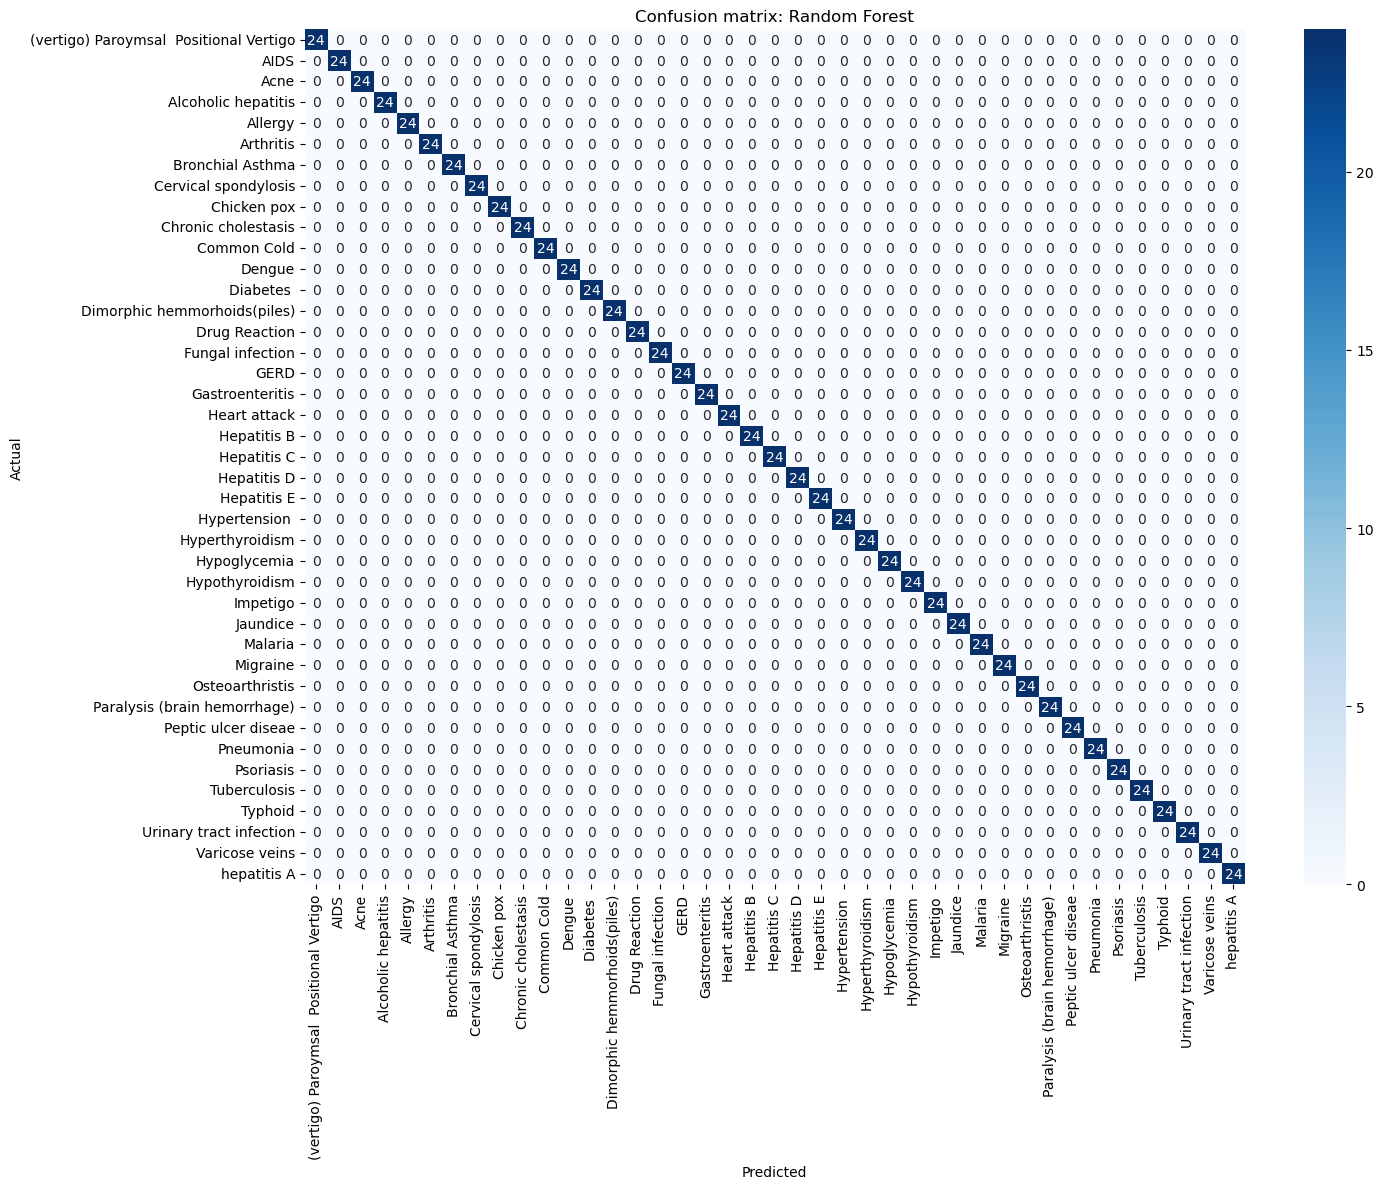

In [17]:
#confusion matrix
cm=confusion_matrix(y_test,rf_pred)
fig,ax=plt.subplots(figsize=(15,12))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=ax,
           xticklabels=le.classes_, yticklabels=le.classes_)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion matrix: Random Forest')
plt.tight_layout()
plt.savefig('../assets/confusion_matrix.png',dpi=150)
plt.show()

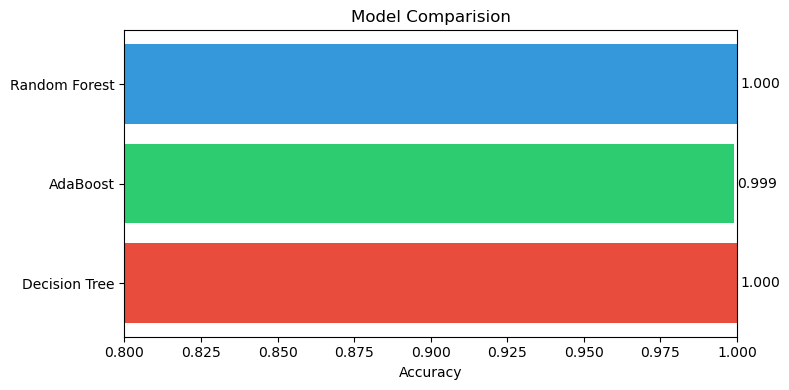

In [19]:
#model comparision chart
results={
    'Decision Tree':accuracy_score(y_test,dt_pred),
    'AdaBoost':accuracy_score(y_test,ada_pred),
    'Random Forest':accuracy_score(y_test,rf_pred)
}
fig,ax=plt.subplots(figsize=(8,4))
bars=ax.barh(list(results.keys()), list(results.values()), color=['#e74c3c','#2ecc71','#3498db'])
ax.set_xlim(0.8,1.0)
ax.set_xlabel('Accuracy')
ax.set_title('Model Comparision')

for bar,val in zip(bars,results.values()):
    ax.text(val+0.001, bar.get_y()+bar.get_height()/2, f'{val:.3f}',va='center')
plt.tight_layout()
plt.savefig('../assets/model_comparison.png',dpi=150)
plt.show()

In [20]:
joblib.dump(rf,'../model/random_forest.pkl')

['../model/random_forest.pkl']

In [21]:
df_sample=df.sample(100,random_state=42)
df_sample.to_csv('../data/sample_disease.csv',index=False)